In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
city = '北京'

In [3]:
housing = pd.read_csv(f'processed_data/{city}/04_data.csv')

In [4]:
print(housing.columns.tolist())

['城市', '区域', '板块', 'price', 'unit_price', '配备电梯', '挂牌时间', '上次交易', '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份', 'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry', 'log_price', 'log_unit_price', 'area', 'distance_to_center', 'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私

In [5]:
stats = housing.drop(columns=['城市', '区域', '板块', '挂牌时间', '上次交易', '核心卖点', '户型介绍', '周边配套', '交通出行'
                              ,'nearest_park_index','nearest_park_industry','x','y'])

In [6]:
from utils import Display
Display(stats)

Shape: (261159, 93)
Index(['price', 'unit_price', '配备电梯', '产权所属', '年份', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center',
       'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交

,Missing,Unique,Dtype
price,0,2818,float64
unit_price,0,99366,float64
配备电梯,0,2,int64
产权所属,0,2,int64
年份,1193,8,float64
...,...,...,...
category_is_Others,0,2,int64
category_is_High-Tech,0,2,int64
category_is_General-Mfg,0,2,int64
category_is_Heavy-Nuisance,0,2,int64


【col: price】
  - 450.0: 1974 次
  - 550.0: 1686 次
  - 420.0: 1667 次
  - 320.0: 1663 次
  - 330.0: 1647 次
----------------------------------------
【col: unit_price】
  - 100000.0: 112 次
  - 50000.0: 43 次
  - 125000.0: 41 次
  - 45455.0: 39 次
  - 62500.0: 37 次
----------------------------------------
【col: 配备电梯】
  - 1: 148836 次
  - 0: 112323 次
----------------------------------------
【col: 产权所属】
  - 2: 228758 次
  - 1: 32401 次
----------------------------------------
【col: 年份】
  - 2023.0: 133246 次
  - 2022.0: 102997 次
  - 2021.0: 12168 次
  - 2024.0: 9499 次
  - 2020.0: 1364 次
----------------------------------------
【col: nearest_park_dist_km】
  - 1.0558044660826411: 531 次
  - 0.1682971198726757: 527 次
  - 0.2633951853487862: 523 次
  - 12.279585246760934: 517 次
  - 1.251156431953514: 494 次
----------------------------------------
【col: log_price】
  - 6.1092475827643655: 1974 次
  - 6.309918278226516: 1686 次
  - 6.040254711277414: 1667 次
  - 5.768320995793772: 1663 次
  - 5.799092654460526: 1647 

In [18]:
missing_cols = stats.isnull().sum()
print(missing_cols[missing_cols > 0])

stats = stats.dropna(subset=['年份'])

年份    1193
dtype: int64


In [19]:
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

Y = stats['log_unit_price']
T = stats['nearest_park_dist_km']


base_cols = ['distance_to_center', 'area','nearest_subway_dist_km','administrative_level','block']
cat_cols = [col for col in stats.columns if col.startswith('category_is_')]
X_cols = base_cols + cat_cols
X = stats[X_cols]


exclude_cols = X_cols + ['log_unit_price', 'nearest_park_dist_km', 'price', 'unit_price', 'log_price']
W_cols = [col for col in stats.columns if col not in exclude_cols]
W = stats[W_cols]


In [20]:
print(W_cols)
print(X_cols)

['配备电梯', '产权所属', '年份', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房', '交易权属_is_一类经济适用房', '交易权属_is_二类经济适用房', '交易权属_is_央产房', '交易权属_is_限价商品房', '交易权属_is_定向安置房', '交易权属_is_自住型商品房', '房屋用途_is_普通住宅', '房屋用途_is_别墅', '房屋用途_is_车库', '房屋用途_is_商业办公类', '房屋用途_is_公寓', '房屋用途_is_住宅', '房屋用途_is_酒店式公寓', '房屋用途_is_平房', '房屋用途_is_商务型公寓', '房屋用途_is_公寓（住

In [21]:
T_log = np.log1p(T) 

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

features = pd.concat([X, W], axis=1)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

print("数据标准化完成")
print(f"特征数量: {features_scaled.shape[1]}")

数据标准化完成
特征数量: 88


In [23]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, X_full, y_full):
    alpha = trial.suggest_float('alpha', 1e-5, 10.0, log=True)
    
    model = LassoCV(
        alphas=[alpha],
        cv=3,
        max_iter=10000,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_full, y_full)
    
    score = model.score(X_full, y_full)
    
    return score

SEED = 42
sampler = optuna.samplers.TPESampler(seed=SEED)

print("🚀 正在优化 Model_Y (房价预测)...")
study_y = optuna.create_study(direction='maximize', sampler=sampler)
study_y.optimize(lambda trial: objective(trial, features_scaled, Y), n_trials=20)
best_alpha_y = study_y.best_params['alpha']

print("\n🚀 正在优化 Model_T (干预项预测)...")
study_t = optuna.create_study(direction='maximize', sampler=sampler)
study_t.optimize(lambda trial: objective(trial, features_scaled, T_log), n_trials=20)
best_alpha_t = study_t.best_params['alpha']

print("-" * 30)
print(f"Model_Y 最佳 alpha: {best_alpha_y:.6f}, R²: {study_y.best_value:.4f}")
print(f"Model_T 最佳 alpha: {best_alpha_t:.6f}, R²: {study_t.best_value:.4f}")

🚀 正在优化 Model_Y (房价预测)...

🚀 正在优化 Model_T (干预项预测)...
------------------------------
Model_Y 最佳 alpha: 0.000010, R²: 0.8716
Model_T 最佳 alpha: 0.000011, R²: 0.2016


In [24]:
from sklearn.linear_model import Lasso

model_y = Lasso(
    alpha=best_alpha_y,
    max_iter=10000,
    random_state=42
)

model_t = Lasso(
    alpha=best_alpha_t,
    max_iter=10000,
    random_state=42
)

print("Lasso 模型创建完成")

Lasso 模型创建完成


In [25]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

model_y.fit(features_scaled, Y)
model_t.fit(features_scaled, T_log)

print("Model_Y 训练完成")
print("Model_T 训练完成")

feature_importance_y = pd.DataFrame({
    'feature': features.columns,
    'coefficient': model_y.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

feature_importance_t = pd.DataFrame({
    'feature': features.columns,
    'coefficient': model_t.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

print("\n=== Model_Y 特征重要性 (Top 20) ===")
print(feature_importance_y.head(20))

print("\n=== Model_T 特征重要性 (Top 20) ===")
print(feature_importance_t.head(20))

Model_Y 训练完成
Model_T 训练完成

=== Model_Y 特征重要性 (Top 20) ===
                      feature  coefficient
4                       block     0.289793
0          distance_to_center    -0.180577
67                 房屋用途_is_车库    -0.104320
65               房屋用途_is_普通住宅     0.093090
16                  bathrooms     0.057197
1                        area    -0.048145
3        administrative_level     0.047122
48                  elevators    -0.042815
50  elevators_household_ratio     0.035808
2      nearest_subway_dist_km     0.034834
46                 装修情况_is_其它     0.028922
66                 房屋用途_is_别墅     0.028897
27         floor_level_is_地下室    -0.026125
37               建筑结构_is_混合结构    -0.025970
15                   kitchens     0.025876
68              房屋用途_is_商业办公类    -0.024001
10                       配备电梯     0.021700
28                  房屋朝向_is_南     0.021566
70                 房屋用途_is_住宅    -0.020381
85                 房源标签_is_地铁     0.019781

=== Model_T 特征重要性 (Top 20) ===
       

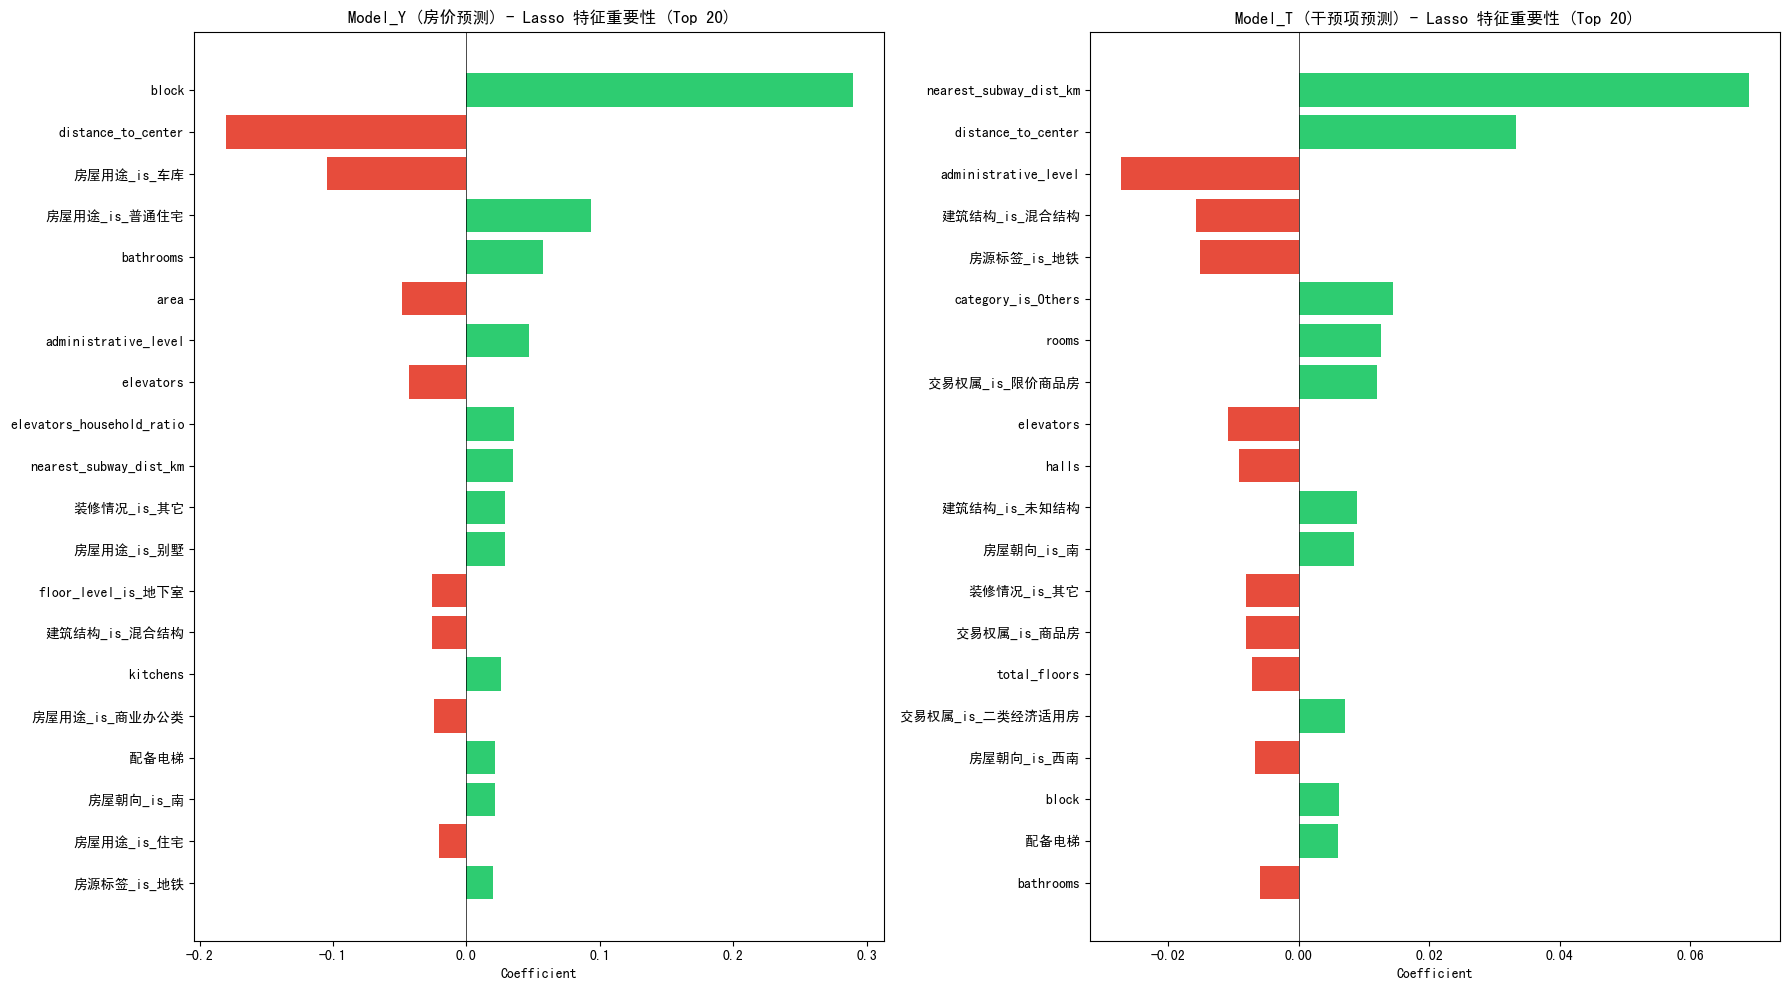


特征重要性图已保存至 lasso_feature_importance.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_n = 20

ax1 = axes[0]
top_features_y = feature_importance_y.head(top_n)
colors_y = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_features_y['coefficient']]
bars1 = ax1.barh(range(len(top_features_y)), top_features_y['coefficient'].values, color=colors_y)
ax1.set_yticks(range(len(top_features_y)))
ax1.set_yticklabels(top_features_y['feature'].values)
ax1.invert_yaxis()
ax1.set_xlabel('Coefficient')
ax1.set_title(f'Model_Y (房价预测) - Lasso 特征重要性 (Top {top_n})')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax2 = axes[1]
top_features_t = feature_importance_t.head(top_n)
colors_t = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_features_t['coefficient']]
bars2 = ax2.barh(range(len(top_features_t)), top_features_t['coefficient'].values, color=colors_t)
ax2.set_yticks(range(len(top_features_t)))
ax2.set_yticklabels(top_features_t['feature'].values)
ax2.invert_yaxis()
ax2.set_xlabel('Coefficient')
ax2.set_title(f'Model_T (干预项预测) - Lasso 特征重要性 (Top {top_n})')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('lasso_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n特征重要性图已保存至 lasso_feature_importance.png")

In [29]:
from econml.dml import LinearDML

est = LinearDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=False,
    cv=5,
    random_state=42
)

est.fit(Y, T_log, X=X, W=W, inference='statsmodels')

print("LinearDML 模型训练完成")

LinearDML 模型训练完成


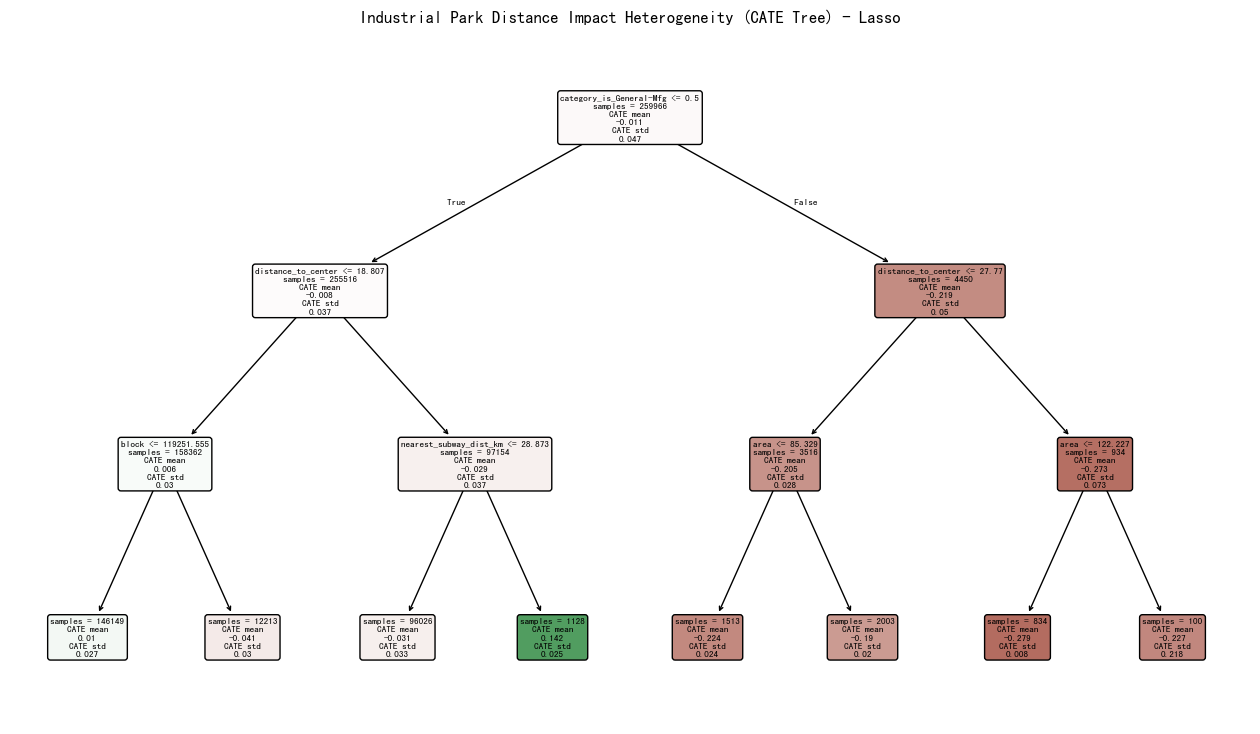

In [31]:
intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=100)
intrp.interpret(est, X)

plt.figure(figsize=(16, 9))
intrp.plot(feature_names=X_cols)
plt.title("Industrial Park Distance Impact Heterogeneity (CATE Tree) - Lasso")
plt.show()

In [32]:
print(est.summary())

                               Coefficient Results                               
                           point_estimate stderr  zstat  pvalue ci_lower ci_upper
---------------------------------------------------------------------------------
distance_to_center                 -0.005    0.0 -15.362    0.0   -0.006   -0.004
area                                  0.0    0.0  10.693    0.0      0.0      0.0
nearest_subway_dist_km              0.009    0.0  19.903    0.0    0.008     0.01
administrative_level                  0.0    0.0   6.911    0.0      0.0      0.0
block                                -0.0    0.0 -10.309    0.0     -0.0     -0.0
category_is_Others                  0.066  0.005  13.886    0.0    0.057    0.075
category_is_High-Tech               0.046  0.006   7.384    0.0    0.034    0.058
category_is_General-Mfg            -0.159  0.012 -12.939    0.0   -0.184   -0.135
category_is_Heavy-Nuisance         -0.009  0.011  -0.809  0.419   -0.029    0.012
category_is_Mode

In [35]:
housing['distance_to_center']

0          3.022736
1         21.951697
2         22.192751
3         17.126073
4          8.180078
            ...    
261154    26.530575
261155     8.324624
261156    68.561531
261157    65.728248
261158    59.853058
Name: distance_to_center, Length: 261159, dtype: float64

In [36]:
housing['nearest_park_dist_km']

0         1.084407
1         0.115074
2         1.236477
3         0.865968
4         0.627199
            ...   
261154    0.715218
261155    0.632755
261156    1.566281
261157    0.225837
261158    0.920171
Name: nearest_park_dist_km, Length: 261159, dtype: float64

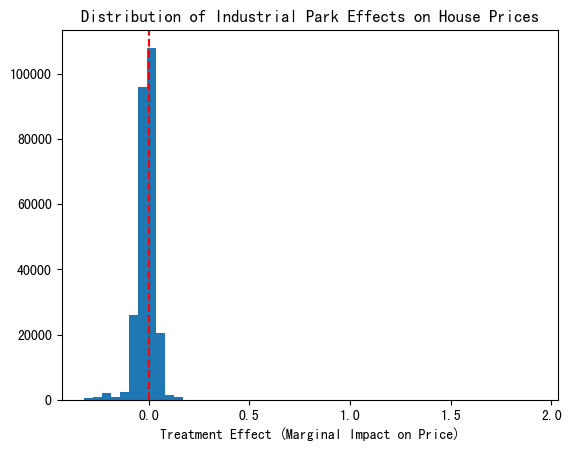

In [34]:
import matplotlib.pyplot as plt

# 1. 计算每个房产点的处理效应 (Conditional Average Treatment Effect)
effects = est.effect(X) # X_test 是你的特征矩阵

# 2. 绘制效应分布图
plt.hist(effects, bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Industrial Park Effects on House Prices")
plt.xlabel("Treatment Effect (Marginal Impact on Price)")
plt.show()

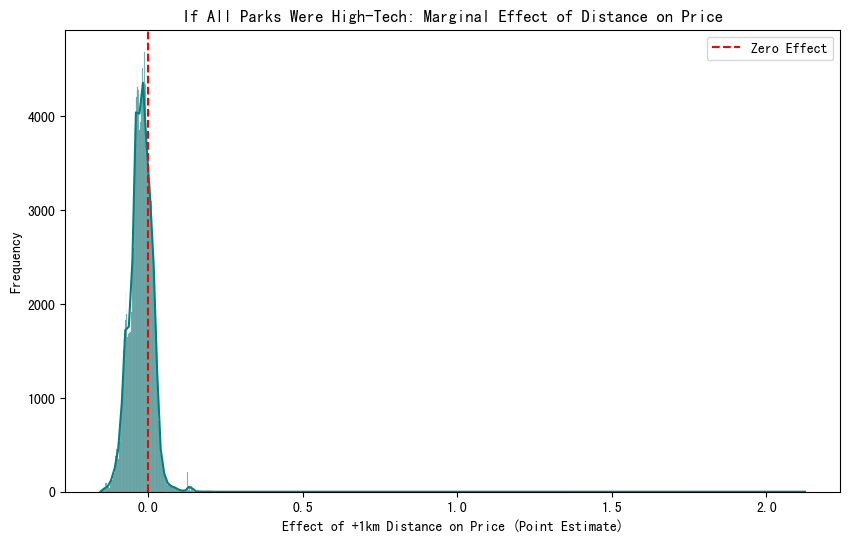

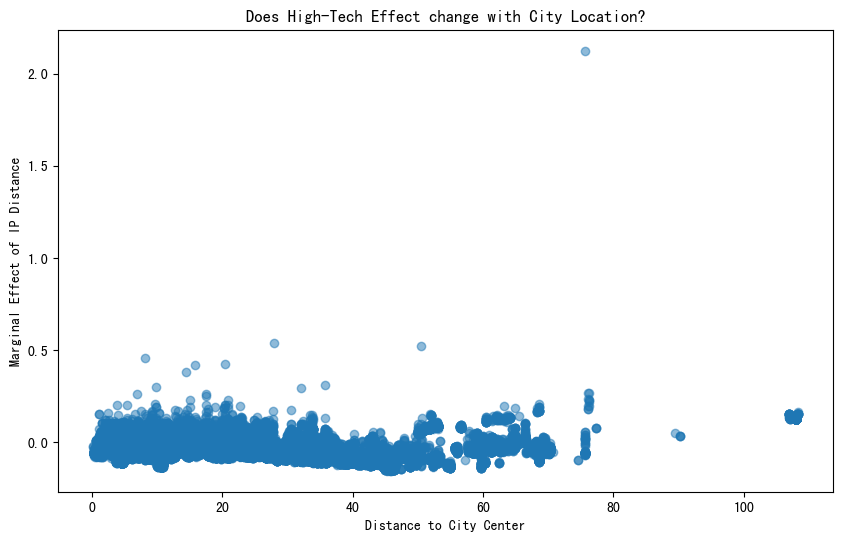

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的特征矩阵叫 X，包含所有 dummy 变量
X_counterfactual = X.copy()

# 1. 强制将所有样本设为“高新技术园”
category_cols = [col for col in X.columns if 'category_is_' in col]
for col in category_cols:
    X_counterfactual[col] = 0
X_counterfactual['category_is_High-Tech'] = 1

# 2. 计算在这种反事实情况下的处理效应（即：距离每增加1单位，房价变动多少）
# 注意：est 是你训练好的 EconML 模型
cfe_effects = est.effect(X_counterfactual)

# 3. 可视化
plt.figure(figsize=(10, 6))
sns.histplot(cfe_effects, kde=True, color='teal')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Effect')
plt.title("If All Parks Were High-Tech: Marginal Effect of Distance on Price")
plt.xlabel("Effect of +1km Distance on Price (Point Estimate)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 4. 看看这个效应和“距离市中心”的关系（找出为何系数为正）
plt.figure(figsize=(10, 6))
plt.scatter(X['distance_to_center'], cfe_effects, alpha=0.5)
plt.title("Does High-Tech Effect change with City Location?")
plt.xlabel("Distance to City Center")
plt.ylabel("Marginal Effect of IP Distance")
plt.show()